In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully")

Libraries imported successfully


In [4]:
df=pd.read_csv(r"C:\Users\ELCOT\Downloads\titanic\train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Titanic Dataset - Exploratory Data Analysis
## Objective: Extract insights using visual and statistical exploration
### Dataset: Titanic Training Data (891 passengers, 12 columns)

In [6]:
print("Data shape:",df.shape)
print("\n")
print("Dataset info")
print(df.info())


Data shape: (891, 12)


Dataset info
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [7]:
print("Statistical Summary")
df.describe()

Statistical Summary


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
print("Missing values in each column")
print(df.isnull().sum())
print("\n")
print("\nMissing Value Percentage")
print(round(df.isnull().sum()/len(df)* 100,2))

Missing values in each column
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64



Missing Value Percentage
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


### Missing Value Heatmap

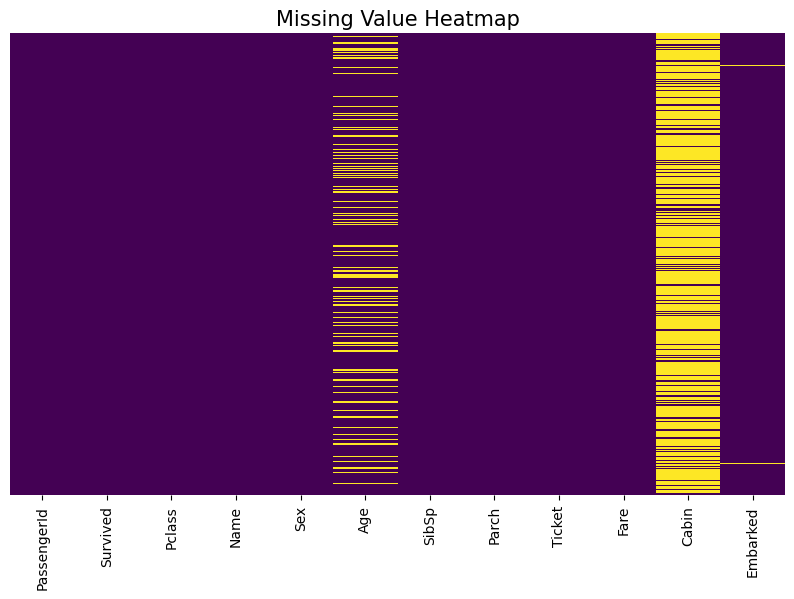

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.title('Missing Value Heatmap',fontsize=15)
plt.show()

In [13]:
df['Age']=pd.to_numeric(df['Age'],errors='coerce')
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df=df.drop(columns=['Cabin'])
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


 # Univariate Analysis

## Survival Count

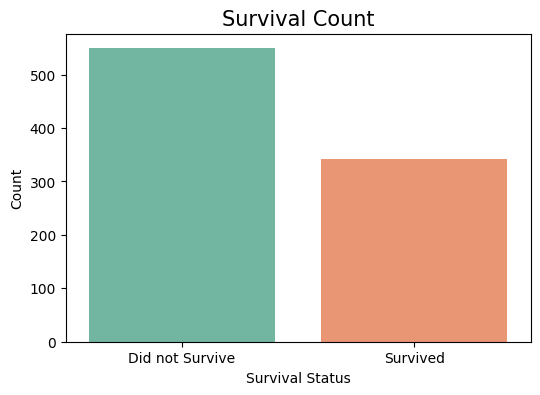

Survival Value Counts:
Survived
0    549
1    342
Name: count, dtype: int64


In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived',data=df,palette='Set2')
plt.title('Survival Count',fontsize=15)
plt.xticks([0,1],['Did not Survive','Survived'])
plt.xlabel('Survival Status')
plt.ylabel('Count')
plt.show()
print("Survival Value Counts:")
print(df['Survived'].value_counts())

## Gender Distribution

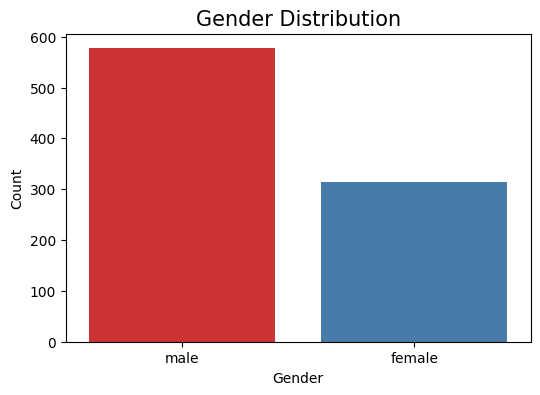

Gender Value Counts:
Sex
male      577
female    314
Name: count, dtype: int64


In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex',data=df,palette='Set1')
plt.title('Gender Distribution',fontsize=15)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()
print("Gender Value Counts:")
print(df['Sex'].value_counts())

## Age Distribution — Histogram

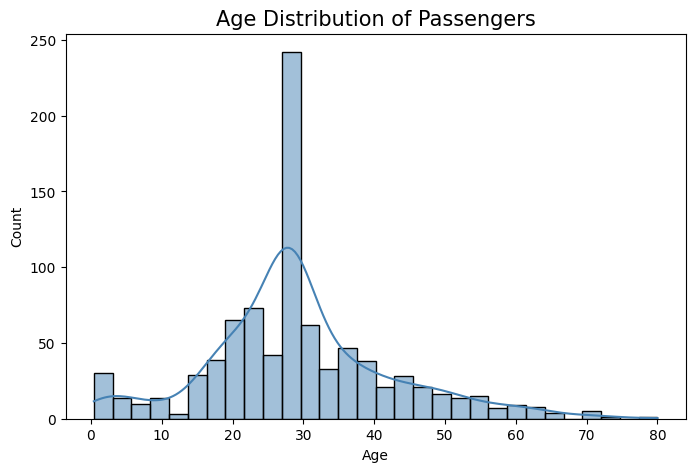

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'],bins=30,kde=True,color='steelblue')
plt.title('Age Distribution of Passengers',fontsize=15)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## Passenger Class Distribution

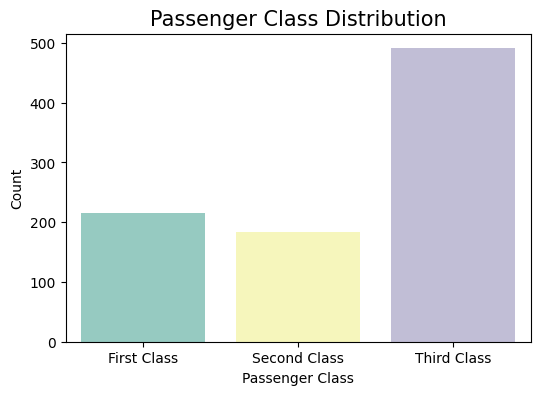

Passenger Class Value Counts:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass',data=df,palette='Set3')
plt.title('Passenger Class Distribution',fontsize=15)
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.xticks([0,1,2],['First Class','Second Class','Third Class'])
plt.show()
print("Passenger Class Value Counts:")
print(df['Pclass'].value_counts())
                    

# Bivariate Analysis

## Survival by Gender

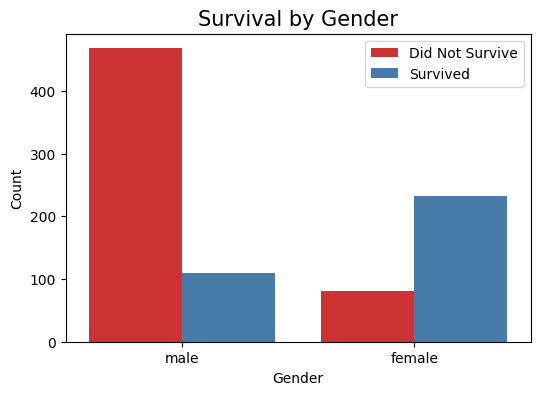

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex',hue='Survived',data=df,palette='Set1')
plt.title('Survival by Gender',fontsize=15)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Did Not Survive','Survived'])
plt.show()

## Age vs Survival Boxplot

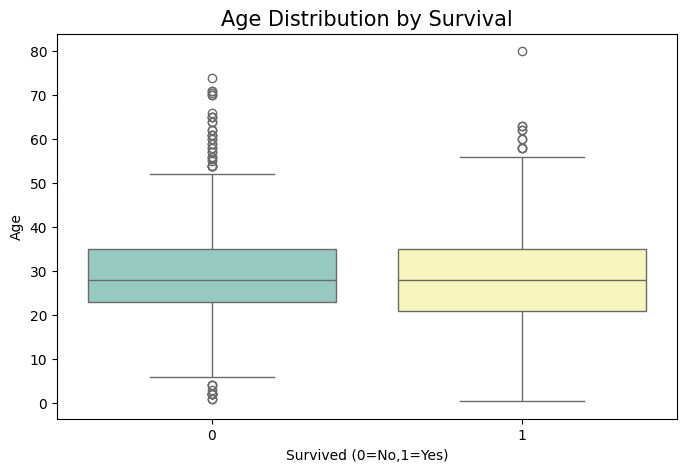

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived',y='Age',data=df,palette='Set3')
plt.title('Age Distribution by Survival', fontsize=15)
plt.xlabel('Survived (0=No,1=Yes)')
plt.ylabel('Age')
plt.show()


# Multivariate Analysis

## Correlation Heatmap

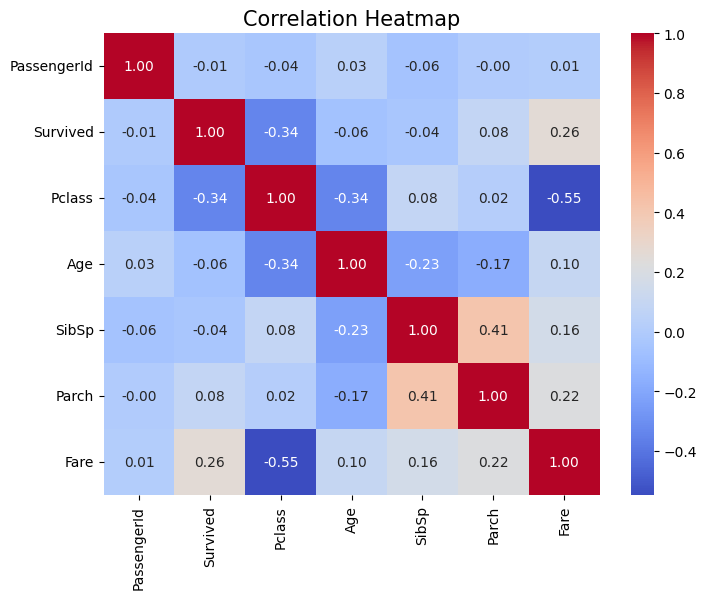

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap',fontsize=15)
plt.show()

## Pairplot

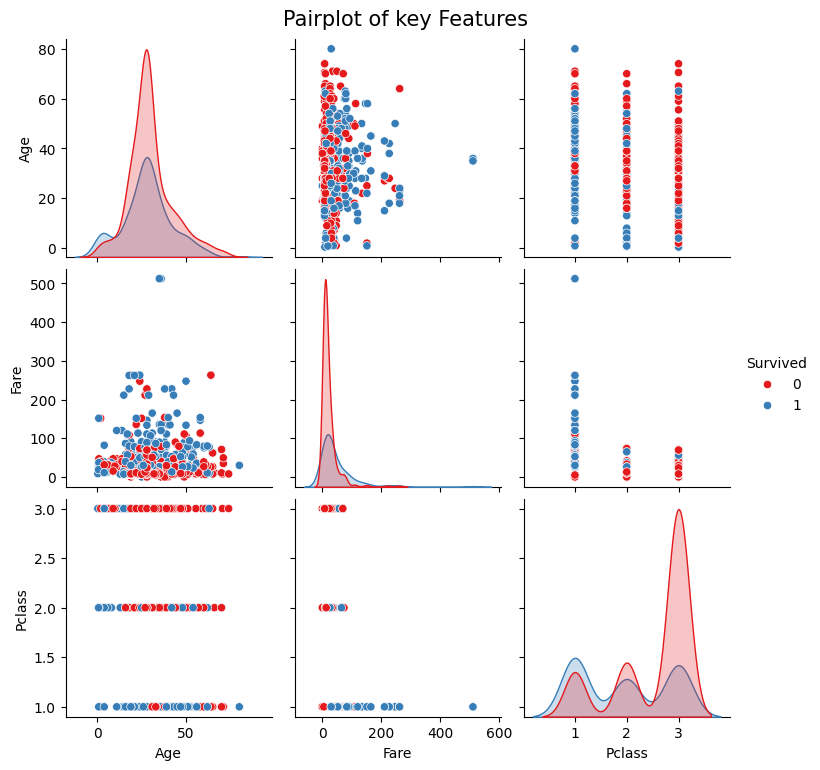

In [29]:
sns.pairplot(df[['Age','Fare','Pclass','Survived']],hue='Survived',palette='Set1')
plt.suptitle('Pairplot of key Features',y=1.02,fontsize=15)
plt.show()

 # Key Findings and Summary

## Key Insights from Titanic EDA

## 1. Survival Rate
Only 38% of passengers survived (342 out of 891 passengers).
Majority of passengers did not survive the disaster.

## 2. Gender Impact
Women had a much higher survival rate than men.
The Women and Children First policy is clearly visible in the data.
Most male passengers did not survive while most female passengers survived.

## 3. Passenger Class Impact
First class passengers survived more than second and third class.
Third class had the most passengers but the lowest survival rate.
Wealthier passengers had better access to lifeboats.

## 4. Age Distribution
Most passengers were between 20 and 35 years old.
Age alone was not a strong predictor of survival.
Both survivors and non survivors had similar median age of around 28 to 30.

## 5. Fare and Class Correlation
Higher fare is strongly linked to higher passenger class with a correlation of -0.55.
Passengers who paid higher fares had better survival chances.
Fare and Survival show a positive correlation of 0.26.

## 6. Missing Data Handling
Age column had 19.87 percent missing values filled with median age.
Cabin column had 77.10 percent missing values and was dropped entirely.
Embarked column had 2 missing values filled with mode value.

## Conclusion
The most important factors affecting survival on the Titanic were Gender,
Passenger Class, and Fare paid. Social status and gender played a significant
role in determining who survived the disaster. This EDA successfully identified
key patterns, trends, and relationships within the Titanic dataset.